**PHASE 1: MODEL DECISION & TESTING**

In this phase, we will be focusing on deciding the forecasting model involving AR/MA and GARCH model, and train-test split for testing.

**I. Introduction & preparation**

Below are the list of used libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
!pip install arch #arch module is not inherently installed, we need to install it manually
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 20.8 MB/s eta 0:00:00


We fetch the bitcoin price data from Yahoo Finance (yfinance) ranging from year 2018 to present. Running the below code will fetch the most current version of the data.

In [3]:
btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
btc = btc[['Close']]
btc.dropna(inplace=True)

/tmp/ipykernel_3746/1845003171.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed


We can run the below code to observe the movement of bitcoin price.

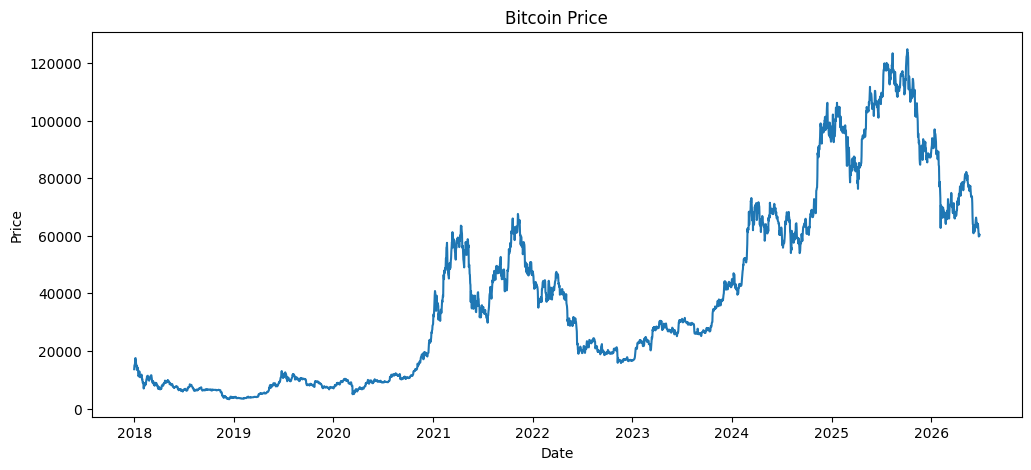

In [4]:
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Close"], label="Close Price")
plt.title("Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Here, we observe that the price movement shows many ups and downs throughout the period, meaning that the price of bitcoin is very volatile. This is the goal of this project: to forecast the volatility of bitcoin.

(More detail on why are we interested in the volatility will be explained in the later part in this notebook)

**II. Methodologies**